In [1]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

Successfully loaded 40506 pairs.

========== INTRA-CLUSTER ANALYSIS (Most Frequent Items) ==========

--- Analyzing Cluster: Support ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


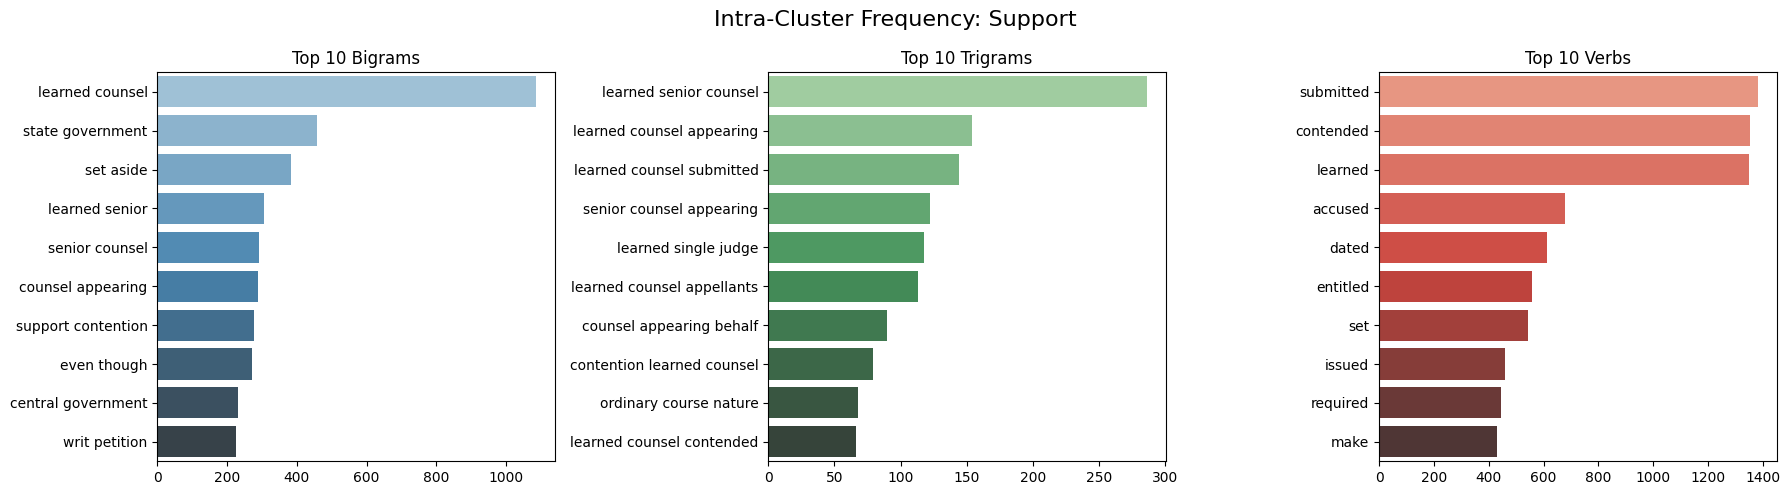


--- Analyzing Cluster: Attack ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


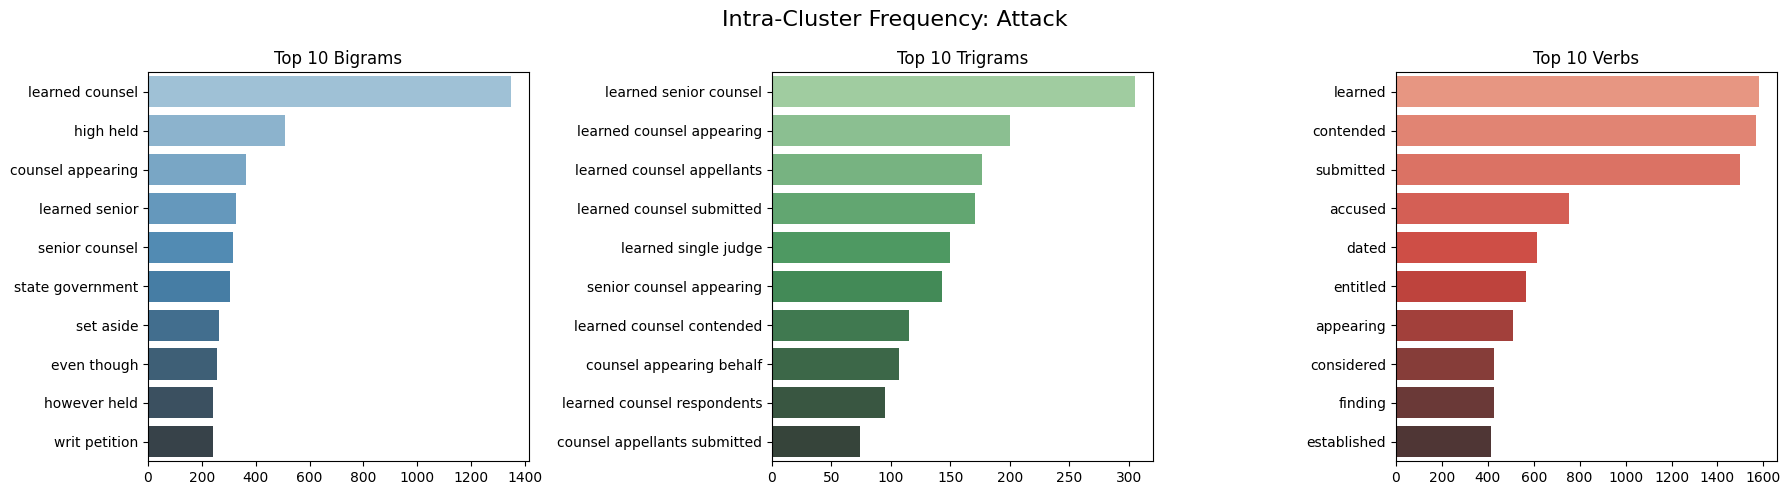


--- Analyzing Cluster: No Relation ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


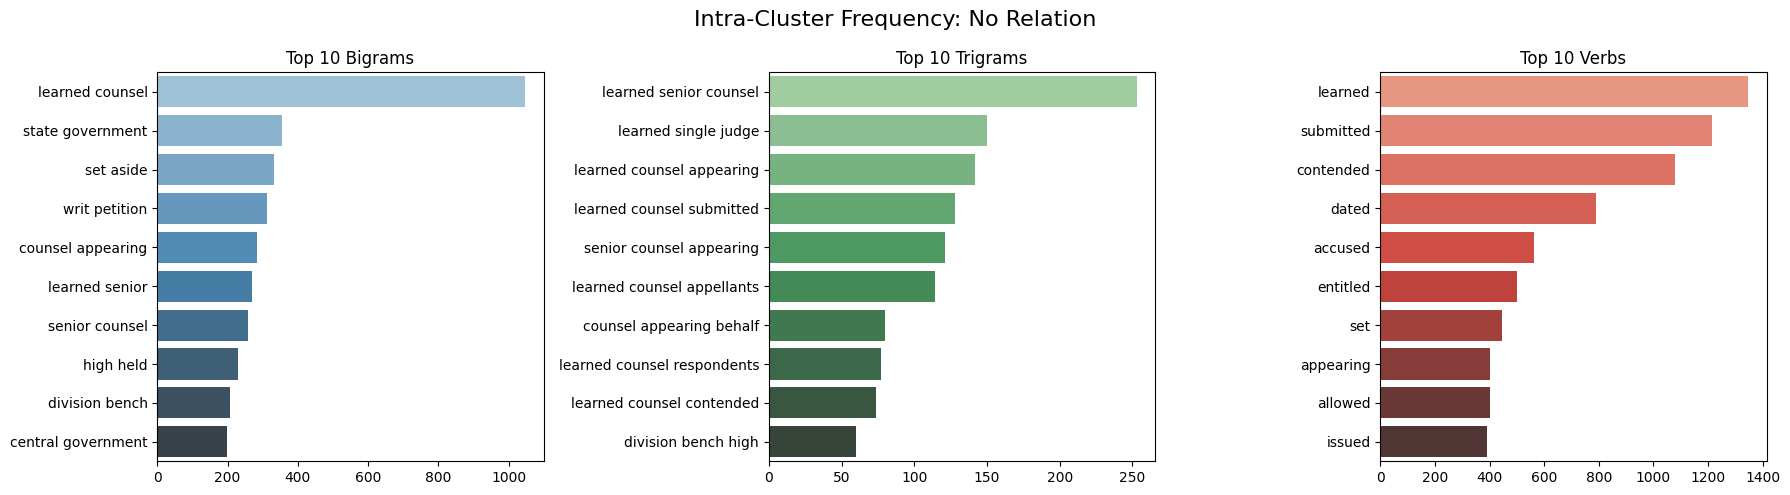


========== INTER-CLUSTER ANALYSIS (Distinct/Unique Items) ==========
Calculating what makes each cluster unique (TF-IDF)...


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


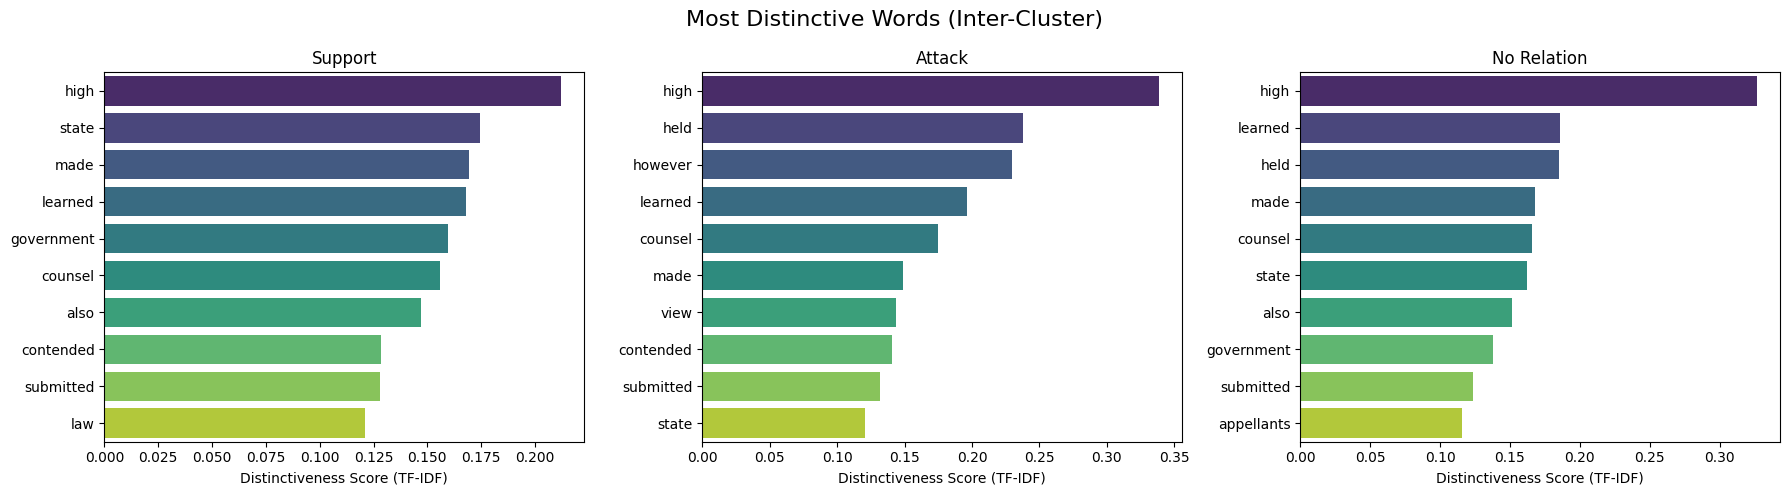

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


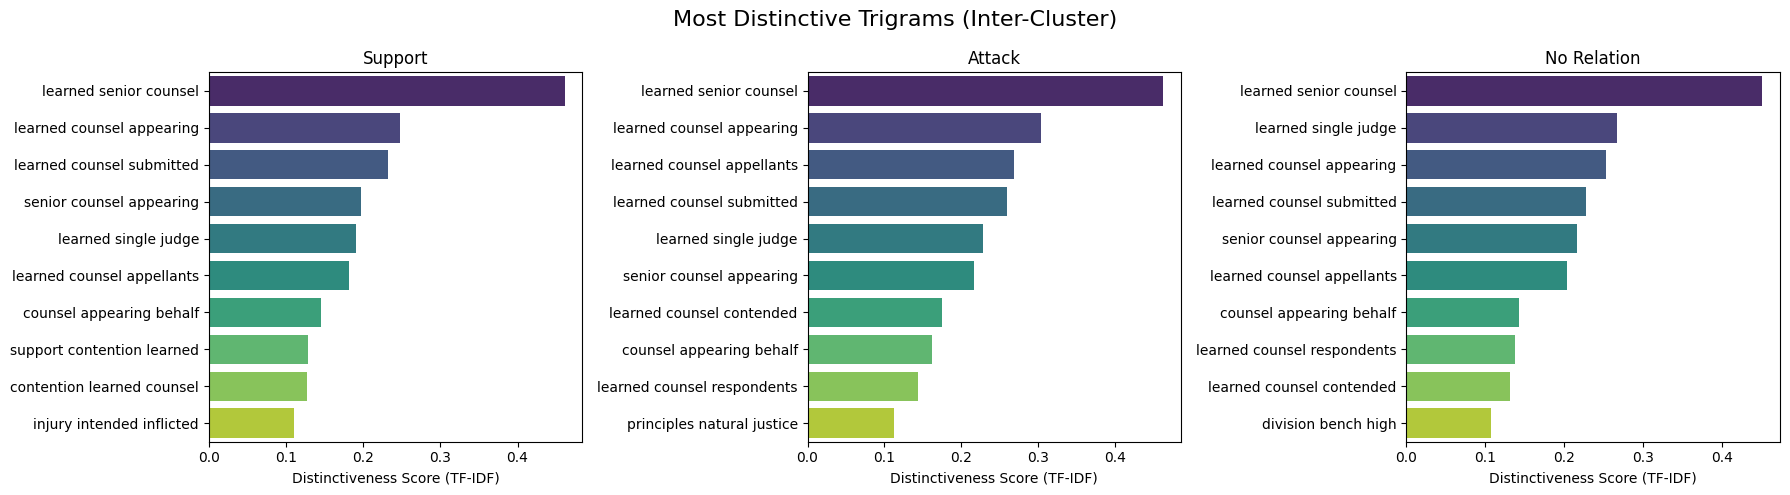

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


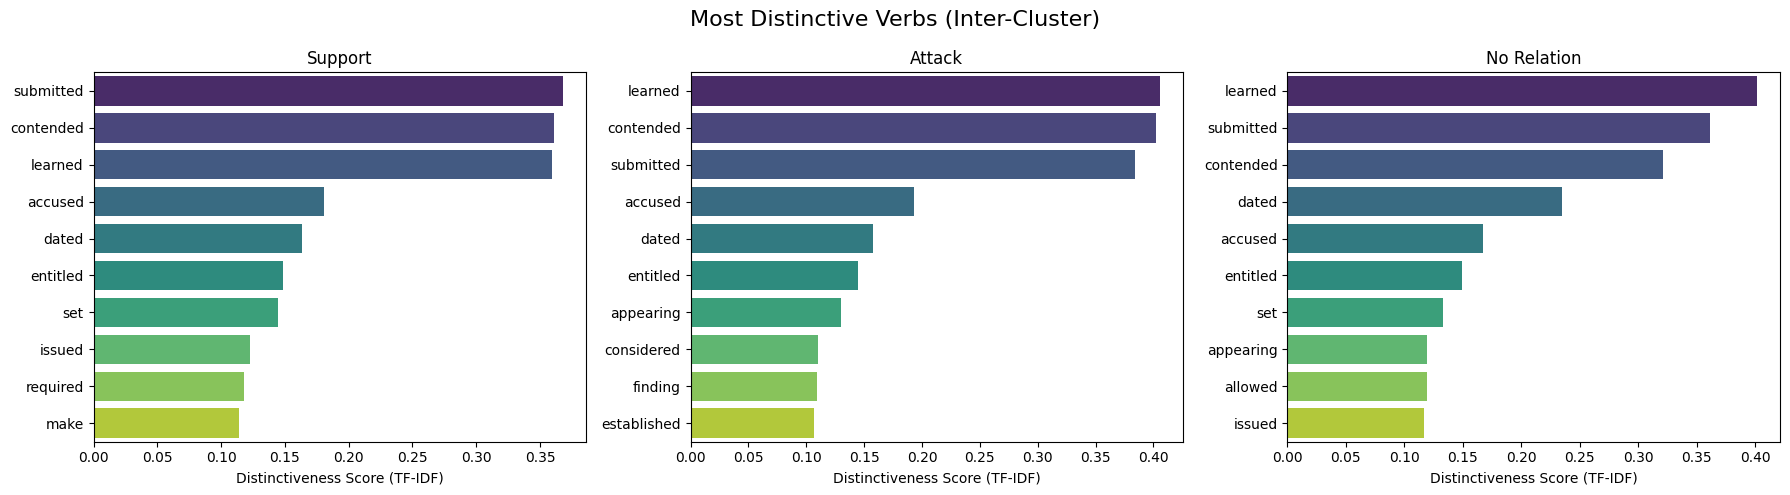

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import os

# --- 1. Robust NLTK Setup ---
for resource in ['tokenizers/punkt', 'taggers/averaged_perceptron_tagger_eng', 'corpora/stopwords']:
    try:
        nltk.data.find(resource)
    except LookupError:
        try: nltk.download(resource.split('/')[-1])
        except: pass

# --- 2. Configuration (Stopwords & Verb Filters) ---

# A. General Stopwords (Prepositions, articles)
MANUAL_STOPWORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours', 
    'he', 'him', 'his', 'she', 'her', 'hers', 'it', 'its', 'they', 'them', 'their', 
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are', 
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 
    'than', 'too', 'very', 'can', 'will', 'just', 'don', 'should', 'now'
}

# B. Legal Nouns to Filter (Context specific)
CUSTOM_LEGAL_STOPWORDS = set([
    'petitioner', 'respondent', 'plaintiff', 'defendant', 'appellant', 'appellee',
    'court', 'case', 'appeal', 'judgment', 'order', 'section', 'article', 'rule',
    'act', 'code', 'v.', 'vs.', 'et', 'al', 'cir', 'dist', 'no.', 'id.', 'supra',
    'ibid', 'stat', 'u.s.c.', 'cfr', 'proc', 'evid', 'h.r.', 's.ct.', 'f.2d', 'f.3d',
    'shall', 'may', 'must', 'will', 'can', 'would', 'could', 'should',
    'said', 'herein', 'therein', 'whereas', 'therefore', 'accordingly', 'furthermore'
])

# C. Verb Stop List 
# Add generic verbs here that appear everywhere to filter them out
VERB_STOPWORDS = set([
    'said', 'held', 'observed', 'stated', 'made', 'given', 'seen', 'taken', 
    'passed', 'filed', 'found', 'based', 'placed', 'view', 'regard'
])

try:
    FULL_STOPWORDS = set(stopwords.words('english')).union(CUSTOM_LEGAL_STOPWORDS)
except:
    FULL_STOPWORDS = MANUAL_STOPWORDS.union(CUSTOM_LEGAL_STOPWORDS)

def load_data(pos_file="/kaggle/input/lrec-tcs-attack-support/sentencePair.txt", neg_file="/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"):
    # ... (Same loading logic as previous versions)
    rows = []
    LABEL_MAP = {"SUPPORT": "Support", "ATTACK": "Attack", "NO_REL": "No Relation", "NO_REL\n": "No Relation"}
    
    def parse_lrec_line(line):
        parts = line.strip().split("\t")
        fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
        if len(fname_indices) != 2: return None
        try:
            sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
            sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
            label = parts[-1]
            return {"sent1": sent1, "sent2": sent2, "label": label}
        except: return None

    for fp in [pos_file, neg_file]:
        if os.path.exists(fp):
            with open(fp, "r", encoding="utf-8") as f:
                for line in f:
                    if parsed := parse_lrec_line(line): rows.append(parsed)
        else: print(f"Warning: {fp} not found.")
            
    if not rows: return pd.DataFrame()
    df = pd.DataFrame(rows)
    df['label'] = df['label'].str.strip().map(LABEL_MAP)
    return df.dropna(subset=['label', 'sent1', 'sent2'])

# --- 3. Robust Processing Functions ---

def get_tokens_and_verbs_robust(text_list):
    all_tokens = []
    all_verbs = []
    
    pos_tagging_available = True
    try: nltk.pos_tag(['test'])
    except LookupError: pos_tagging_available = False

    for text in text_list:
        text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
        
        try: tokens = word_tokenize(text)
        except LookupError: tokens = re.findall(r'\b\w+\b', text)
        
        # Filter tokens
        clean_tokens = [t for t in tokens if t not in FULL_STOPWORDS and len(t) > 2]
        all_tokens.extend(clean_tokens)
        
        # Verb Extraction
        if pos_tagging_available:
            try:
                tagged = nltk.pos_tag(clean_tokens)
                # Filter by POS tag AND Verb Stop List
                verbs = [word for word, tag in tagged if tag.startswith('VB') and word not in VERB_STOPWORDS]
                all_verbs.extend(verbs)
            except: pass
        else:
            # Fallback Heuristic
            possible_verbs = [
                t for t in clean_tokens 
                if (t.endswith('ed') or t.endswith('ing')) and t not in VERB_STOPWORDS
            ]
            all_verbs.extend(possible_verbs)
                    
    return all_tokens, all_verbs

# --- 4. Inter-Cluster Difference Analysis (TF-IDF) ---

def get_distinctive_ngrams(corpus_dict, ngram_range=(1,1), top_n=10):
    """Calculates TF-IDF to find unique terms/ngrams for each cluster."""
    labels = list(corpus_dict.keys())
    corpus = list(corpus_dict.values())
    
    tfidf = TfidfVectorizer(stop_words=None, ngram_range=ngram_range, max_features=2000)
    try:
        tfidf_matrix = tfidf.fit_transform(corpus)
        feature_names = tfidf.get_feature_names_out()
    except ValueError:
        return None

    distinctive_data = {}
    for i, label in enumerate(labels):
        row = tfidf_matrix[i].toarray().flatten()
        top_indices = row.argsort()[::-1][:top_n]
        top_features = [(feature_names[idx], row[idx]) for idx in top_indices if row[idx] > 0]
        distinctive_data[label] = top_features
    return distinctive_data

def plot_distinctive_terms(distinctive_data, title):
    if not distinctive_data: return
    num_clusters = len(distinctive_data)
    fig, axes = plt.subplots(1, num_clusters, figsize=(6 * num_clusters, 5))
    fig.suptitle(title, fontsize=16)
    if num_clusters == 1: axes = [axes]

    for i, (label, terms) in enumerate(distinctive_data.items()):
        if not terms: continue
        words, scores = zip(*terms)
        sns.barplot(x=list(scores), y=list(words), ax=axes[i], palette='viridis')
        axes[i].set_title(f'{label}')
        axes[i].set_xlabel('Distinctiveness Score (TF-IDF)')
    plt.tight_layout()
    plt.show()

# --- Main Analysis Orchestrator ---

def analyze_full_pipeline(df):
    melted_df = pd.melt(df, id_vars=['label'], value_vars=['sent1', 'sent2'], value_name='text')
    relations = melted_df['label'].unique()
    
    cluster_text_corpus = {} # For general word analysis
    cluster_verb_corpus = {} # For verb analysis

    # 1. INTRA-CLUSTER Analysis (Frequency)
    print("\n========== INTRA-CLUSTER ANALYSIS (Most Frequent Items) ==========")
    
    for relation in relations:
        print(f"\n--- Analyzing Cluster: {relation} ---")
        subset = melted_df[melted_df['label'] == relation]
        if len(subset) > 20000: subset = subset.sample(20000, random_state=42)
            
        texts = subset['text'].tolist()
        tokens, verbs = get_tokens_and_verbs_robust(texts)
        
        if not tokens: continue

        # Save for Inter-Cluster step
        cluster_text_corpus[relation] = " ".join(tokens)
        cluster_verb_corpus[relation] = " ".join(verbs)

        # Calculate Counts
        bigrams = list(ngrams(tokens, 2))
        trigrams = list(ngrams(tokens, 3))
        
        bigram_counts = Counter(bigrams).most_common(10)
        trigram_counts = Counter(trigrams).most_common(10)
        verb_counts = Counter(verbs).most_common(10)
        
        # Plot Frequency (Intra)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Intra-Cluster Frequency: {relation}', fontsize=16)
        
        def plot_bar(data, ax, title, color):
            if not data: return
            labels, values = zip(*data)
            labels = [" ".join(l) if isinstance(l, tuple) else l for l in labels]
            sns.barplot(x=list(values), y=list(labels), ax=ax, palette=color)
            ax.set_title(title)

        plot_bar(bigram_counts, axes[0], "Top 10 Bigrams", "Blues_d")
        plot_bar(trigram_counts, axes[1], "Top 10 Trigrams", "Greens_d")
        plot_bar(verb_counts, axes[2], "Top 10 Verbs", "Reds_d")
        
        plt.tight_layout()
        plt.show()

    # 2. INTER-CLUSTER Analysis (Distinctiveness)
    print("\n========== INTER-CLUSTER ANALYSIS (Distinct/Unique Items) ==========")
    print("Calculating what makes each cluster unique (TF-IDF)...")
    
    # A. Distinctive Words
    distinctive_words = get_distinctive_ngrams(cluster_text_corpus, ngram_range=(1,1), top_n=10)
    plot_distinctive_terms(distinctive_words, "Most Distinctive Words (Inter-Cluster)")
    
    # B. Distinctive Trigrams (New Request)
    distinctive_trigrams = get_distinctive_ngrams(cluster_text_corpus, ngram_range=(3,3), top_n=10)
    plot_distinctive_terms(distinctive_trigrams, "Most Distinctive Trigrams (Inter-Cluster)")
    
    # C. Distinctive Verbs
    distinctive_verbs = get_distinctive_ngrams(cluster_verb_corpus, ngram_range=(1,1), top_n=10)
    plot_distinctive_terms(distinctive_verbs, "Most Distinctive Verbs (Inter-Cluster)")

if __name__ == "__main__":
    df_data = load_data()
    if not df_data.empty:
        print(f"Successfully loaded {len(df_data)} pairs.")
        analyze_full_pipeline(df_data)
    else:
        print("CRITICAL: Data not found.")